In [ ]:
%pip install pandas numpy scikit-learn matplotlib seaborn notebook


Part A: Spam Classification using GaussianNB and MultinomialNB

In [2]:
# 1. Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, accuracy_score

# 2. Load dataset
df = pd.read_csv('Lab2_dataset.csv')  # Replace with your actual CSV file name
print(df.head())

# 3. Preprocessing: Convert text to features
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['text'])
y = df['label_num']  # 0 = ham, 1 = spam

# 4. Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train GaussianNB (needs dense array)
gnb = GaussianNB()
gnb.fit(X_train.toarray(), y_train)
y_pred_gnb = gnb.predict(X_test.toarray())

# 6. Train MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)

# 7. Evaluation
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("MultinomialNB Accuracy:", accuracy_score(y_test, y_pred_mnb))

print("\nMultinomialNB Classification Report:\n", classification_report(y_test, y_pred_mnb))


   Unnamed: 0 label                                               text  \
0         605   ham  Subject: enron methanol ; meter # : 988291\nth...   
1        2349   ham  Subject: hpl nom for january 9 , 2001\n( see a...   
2        3624   ham  Subject: neon retreat\nho ho ho , we ' re arou...   
3        4685  spam  Subject: photoshop , windows , office . cheap ...   
4        2030   ham  Subject: re : indian springs\nthis deal is to ...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  
GaussianNB Accuracy: 0.9545893719806763
MultinomialNB Accuracy: 0.978743961352657

MultinomialNB Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       742
           1       0.96      0.96      0.96       293

    accuracy                           0.98      1035
   macro avg       0.97      0.97      0.97      1035
weighted avg       0.98      0.98      0.98      1035



- The 'MultinomialNB' classifier performed better than `GaussianNB`, as expected.
- This is because MultinomialNB is better suited for discrete count features like word counts.
- GaussianNB assumes continuous features, which does not suit the sparse count matrix of text data.
- Hence, for text classification (spam vs ham), MultinomialNB is the preferred model.


Part B: Airbnb NYC Dataset – Outlier Removal on Price

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


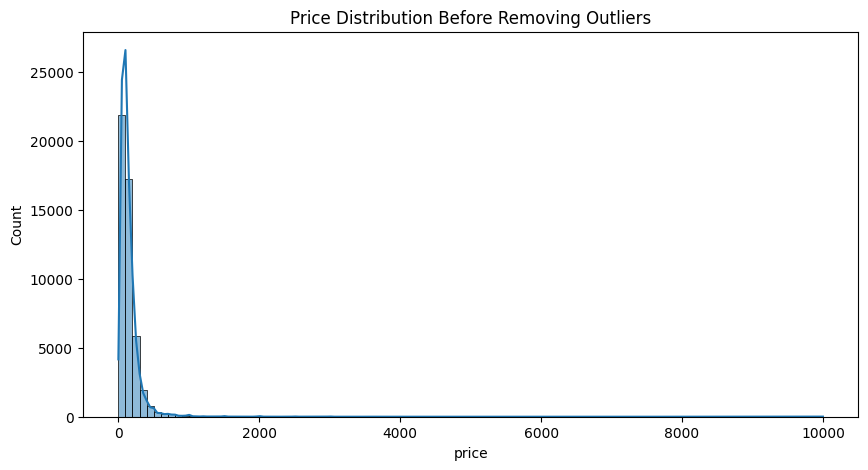

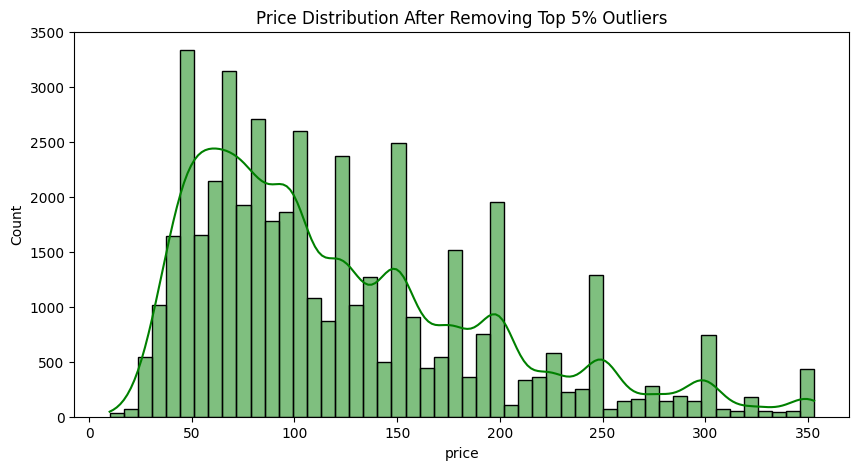

Mean Price (cleaned): 122.56274632265846
Median Price (cleaned): 100.0


In [3]:
# 1. Load data
df = pd.read_csv('AB_NYC_2019.csv')  # Replace with your file name

# 2. Basic exploration
print(df['price'].describe())
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Histogram before cleaning
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=100, kde=True)
plt.title("Price Distribution Before Removing Outliers")
plt.show()

# 4. Remove entries with price <= 0
df = df[df['price'] > 0]

# 5. Using percentile to remove extreme high values
upper_limit = df['price'].quantile(0.95)
df_clean = df[df['price'] < upper_limit]

# 6. Histogram after cleaning
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['price'], bins=50, kde=True, color='green')
plt.title("Price Distribution After Removing Top 5% Outliers")
plt.show()

# 7. Compare Mean vs Median
mean_price = df_clean['price'].mean()
median_price = df_clean['price'].median()

print("Mean Price (cleaned):", mean_price)
print("Median Price (cleaned):", median_price)


- Outliers in price were identified using the 95th percentile approach, removing the top 5% most expensive listings.
- This is better than using the mean alone, as the mean is sensitive to extreme values.
- Median and percentile-based filtering provided a more robust measure to clean the data.
- Final cleaned dataset has a more balanced distribution and will improve downstream modeling performance.
